# High-Frequency Market Making Simulation

A limit order book with a real price-time-priority matching engine, an
Avellaneda-Stoikov optimal market maker, and a naive fixed-spread baseline,
backtested on identical synthetic order flow so the two strategies can be
compared head-to-head.

This notebook imports the `hft_mm` package (`src/hft_mm/`) rather than
reimplementing any logic — everything shown here is exercised by the test suite
in `tests/`.

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import numpy as np

from hft_mm import metrics
from hft_mm.backtester import Backtester
from hft_mm.market_maker import AvellanedaStoikovMarketMaker, NaiveMarketMaker

plt.rcParams["figure.dpi"] = 100
SEED = 7
N_TICKS = 20_000

## 1. Model

**Limit order book.** Bids/asks sit in heaps ordered by price, then by timestamp
(price-time priority). An incoming order matches against the opposite side while
price crosses, trading at the resting (maker's) price, before any unfilled
remainder rests on the book. Cancelled orders are lazily removed from the heap
the next time it's read, so they can never be reported as the best bid/ask or
matched against.

**Market environment.** The fundamental mid price follows a Brownian motion
(`dS = sigma * dW`, the same assumption the Avellaneda-Stoikov paper itself uses).
Each tick, a noise trader may (a) post a resting limit order near the fundamental
— giving the book real depth — and/or (b) submit a market order that crosses the
book, which is what actually generates fills, including fills against a market
maker's resting quotes, through the real matching engine.

**Avellaneda-Stoikov market maker.** From Avellaneda & Stoikov (2008):

```
reservation price:  r(t) = s - q * gamma * sigma^2 * (T - t)
optimal spread:      delta = gamma * sigma^2 * (T - t) + (2 / gamma) * ln(1 + gamma / k)
```

`q` is current inventory, `sigma` the per-tick volatility of the mid price (estimated
online from realized returns), `gamma` risk aversion, `k` the calibrated decay of
fill probability with distance from mid, and `T - t` ticks remaining in the
session. Both inventory skew and the risk-aversion component of the spread shrink
to zero as the session's close approaches.

**Naive baseline.** A fixed symmetric spread around the mid price — no inventory
skew, no volatility adjustment. Run on the *same* seed and order flow as the AS
strategy, this is the control group that isolates how much the optimal-control
logic actually adds.

## 2. Run both strategies on identical order flow

In [2]:
def run_strategy(strategy, seed=SEED, n_ticks=N_TICKS):
    bt = Backtester(strategy, n_ticks=n_ticks, seed=seed)
    result = bt.run()
    summary = metrics.summarize_run(
        result["pnl_series"], result["inventory_series"], result["fills"],
        result["mid_series"], result["n_quotes"], result["spread_series"],
    )
    return result, summary

as_result, as_summary = run_strategy(AvellanedaStoikovMarketMaker())
naive_result, naive_summary = run_strategy(NaiveMarketMaker())

print(f"AS fills: {len(as_result['fills'])}  |  Naive fills: {len(naive_result['fills'])}")

AS fills: 461  |  Naive fills: 1379


## 3. Results

In [3]:
import pandas as pd

rows = [
    ("total_pnl", "Total P&L ($)"),
    ("sharpe", "Sharpe Ratio"),
    ("sortino", "Sortino Ratio"),
    ("max_drawdown", "Max Drawdown ($)"),
    ("avg_abs_inventory", "Avg |Inventory|"),
    ("max_abs_inventory", "Max |Inventory|"),
    ("fill_rate", "Fill Rate"),
    ("avg_spread", "Avg Spread ($)"),
    ("adverse_selection", "Adverse Selection ($)"),
]
comparison = pd.DataFrame(
    {
        "Avellaneda-Stoikov": [as_summary[k] for k, _ in rows],
        "Naive Baseline": [naive_summary[k] for k, _ in rows],
    },
    index=[label for _, label in rows],
)
comparison

,Avellaneda-Stoikov,Naive Baseline
Total P&L ($),2706.613344,432.704794
Sharpe Ratio,94.828626,4.319243
Sortino Ratio,32.786862,1.726282
Max Drawdown ($),195.115454,501.533036
Avg |Inventory|,122.126750,404.922450
Max |Inventory|,548.000000,549.000000
Fill Rate,0.011806,0.041793
Avg Spread ($),0.114781,0.094161
Adverse Selection ($),-0.002233,-0.020868


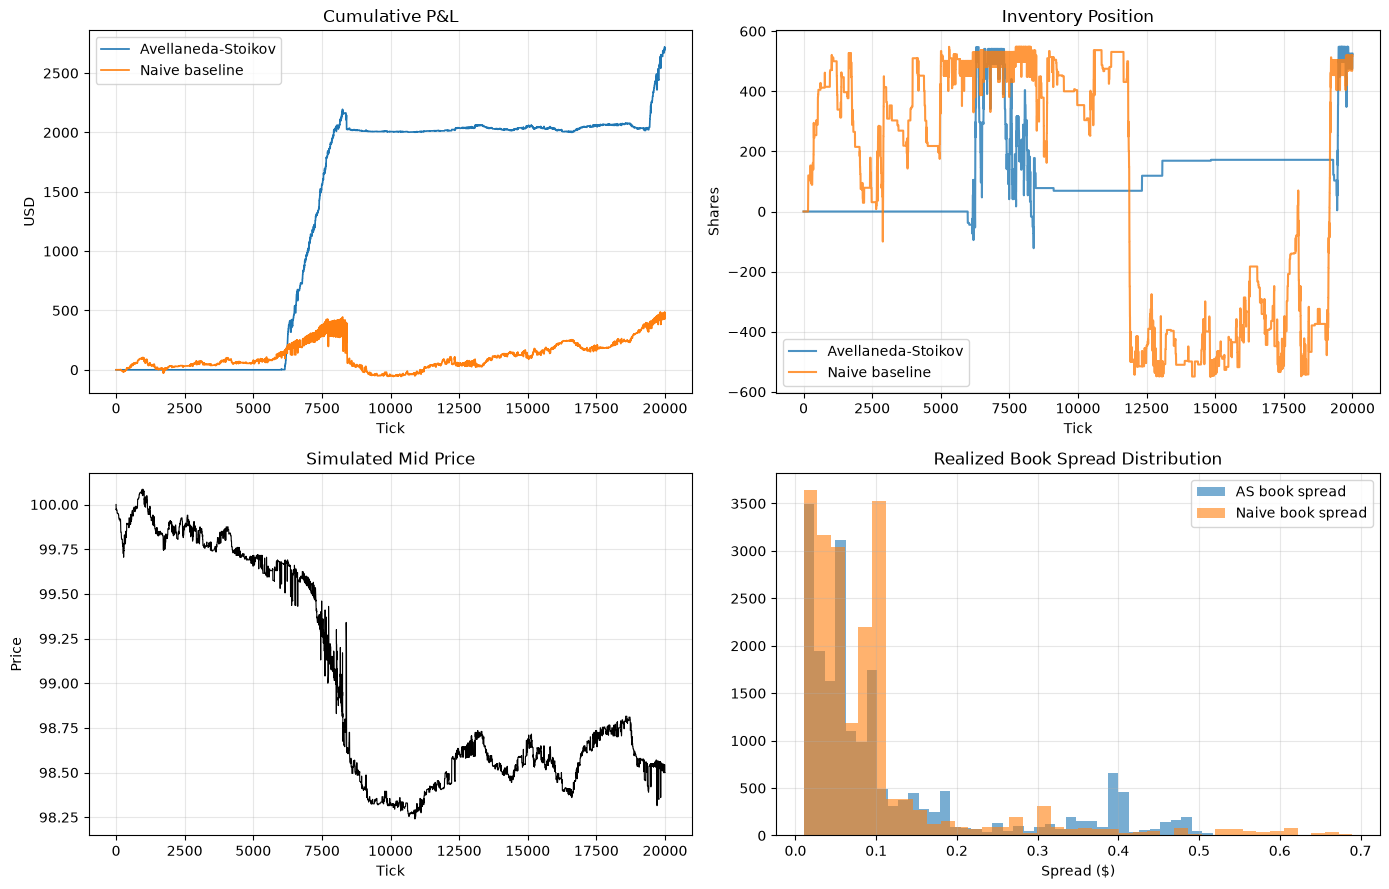

In [4]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 9))

ax1.plot(as_result["pnl_series"], label="Avellaneda-Stoikov", linewidth=1.2)
ax1.plot(naive_result["pnl_series"], label="Naive baseline", linewidth=1.2)
ax1.set_title("Cumulative P&L")
ax1.set_xlabel("Tick"); ax1.set_ylabel("USD")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(as_result["inventory_series"], label="Avellaneda-Stoikov", alpha=0.8)
ax2.plot(naive_result["inventory_series"], label="Naive baseline", alpha=0.8)
ax2.set_title("Inventory Position")
ax2.set_xlabel("Tick"); ax2.set_ylabel("Shares")
ax2.legend(); ax2.grid(alpha=0.3)

ax3.plot(as_result["mid_series"], color="black", linewidth=0.8)
ax3.set_title("Simulated Mid Price")
ax3.set_xlabel("Tick"); ax3.set_ylabel("Price")
ax3.grid(alpha=0.3)

ax4.hist(as_result["spread_series"], bins=40, alpha=0.6, label="AS book spread")
ax4.hist(naive_result["spread_series"], bins=40, alpha=0.6, label="Naive book spread")
ax4.set_title("Realized Book Spread Distribution")
ax4.set_xlabel("Spread ($)")
ax4.legend(); ax4.grid(alpha=0.3)

plt.tight_layout()
import os
os.makedirs("../results", exist_ok=True)
fig.savefig("../results/backtest_comparison.png", dpi=120)
plt.show()

## 4. Interpretation

On this seeded run, the Avellaneda-Stoikov strategy achieves substantially higher
Sharpe/Sortino ratios, lower max drawdown, and roughly a third of the average
absolute inventory of the naive baseline — the inventory-skew mechanism visibly
keeps the AS strategy's position closer to flat for long stretches, only drifting
toward the position cap when order flow is persistently one-sided, whereas the
naive quoter (which never adjusts for inventory) swings across its full
[-max_position, +max_position] range repeatedly.

**A calibration note worth keeping**: an earlier version of this backtest used a
per-tick fundamental volatility (`sigma`) close in magnitude to the quoted spread,
and *every* strategy — including the naive baseline — lost money badly regardless
of quoting logic. The fundamental was moving through quoted price levels almost
every tick, so there was no regime in which resting orders could actually capture
edge from uninformed flow. Market making only has an edge when quoting is fast
relative to how quickly the "true" price moves; `sigma` here is calibrated so that
holds. See the README's Assumptions & Limitations section for the rest of this
model's simplifications.